In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from ucimlrepo import fetch_ucirepo

In [3]:
bank_marketing =fetch_ucirepo(id=222)

X=bank_marketing.data.features

In [4]:
y=bank_marketing.data.targets

In [5]:
bank_marketing

{'data': {'ids': None,
  'features':        age           job   marital  education default  balance housing loan  \
  0       58    management   married   tertiary      no     2143     yes   no   
  1       44    technician    single  secondary      no       29     yes   no   
  2       33  entrepreneur   married  secondary      no        2     yes  yes   
  3       47   blue-collar   married        NaN      no     1506     yes   no   
  4       33           NaN    single        NaN      no        1      no   no   
  ...    ...           ...       ...        ...     ...      ...     ...  ...   
  45206   51    technician   married   tertiary      no      825      no   no   
  45207   71       retired  divorced    primary      no     1729      no   no   
  45208   72       retired   married  secondary      no     5715      no   no   
  45209   57   blue-collar   married  secondary      no      668      no   no   
  45210   37  entrepreneur   married  secondary      no     2971      no  

In [6]:
bank_marketing.variables

,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,None,None,no
1,job,Feature,Categorical,Occupation,"type of job (categorical: 'admin.','blue-colla...",None,no
2,marital,Feature,Categorical,Marital Status,"marital status (categorical: 'divorced','marri...",None,no
3,education,Feature,Categorical,Education Level,"(categorical: 'basic.4y','basic.6y','basic.9y'...",None,no
4,default,Feature,Binary,None,has credit in default?,None,no
5,balance,Feature,Integer,None,average yearly balance,euros,no
6,housing,Feature,Binary,None,has housing loan?,None,no
7,loan,Feature,Binary,None,has personal loan?,None,no
8,contact,Feature,Categorical,None,contact communication type (categorical: 'cell...,None,yes
9,day_of_week,Feature,Date,None,last contact day of the week,None,no


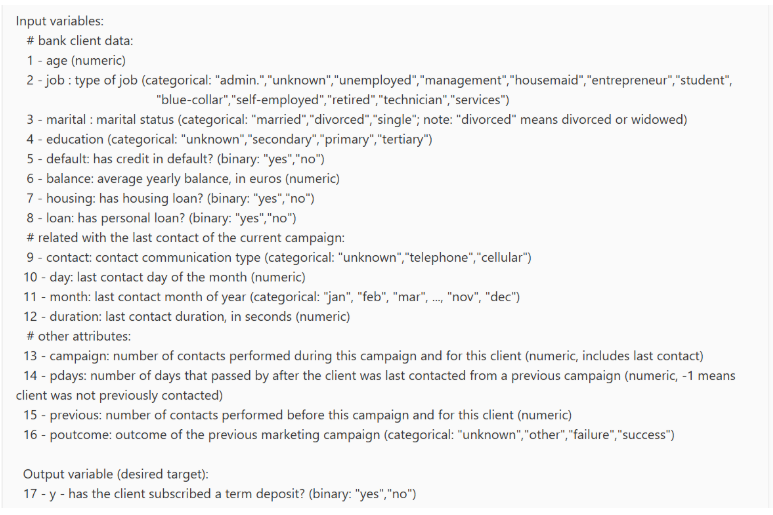

# Objectives

- To Analyse the factors that are responsible for client subscribing a term deposit
- To Create an Predictive model to predict client subscribing a term deposit
- To have an comprehensive understanding of client's information and there behaviour
- To Understand about the Profitability and Risk of alloting an term deposit
- To create an Understanding of Marketing campaign by using previous campaign data through Statistical analysis

## Data Cleaning

In [7]:
df=X.merge(y,on=X.index,how='inner')

In [8]:
df.info

<bound method DataFrame.info of        key_0  age           job   marital  education default  balance housing  \
0          0   58    management   married   tertiary      no     2143     yes   
1          1   44    technician    single  secondary      no       29     yes   
2          2   33  entrepreneur   married  secondary      no        2     yes   
3          3   47   blue-collar   married        NaN      no     1506     yes   
4          4   33           NaN    single        NaN      no        1      no   
...      ...  ...           ...       ...        ...     ...      ...     ...   
45206  45206   51    technician   married   tertiary      no      825      no   
45207  45207   71       retired  divorced    primary      no     1729      no   
45208  45208   72       retired   married  secondary      no     5715      no   
45209  45209   57   blue-collar   married  secondary      no      668      no   
45210  45210   37  entrepreneur   married  secondary      no     2971      no

In [9]:
df.isnull().sum()

key_0              0
age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
y                  0
dtype: int64

<Axes: ylabel='count'>

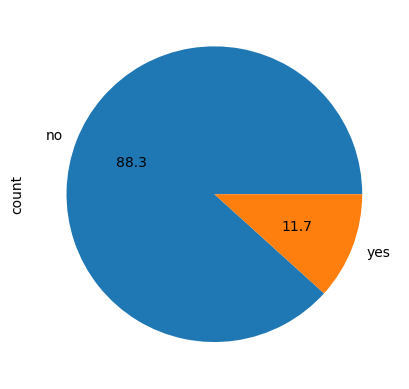

In [10]:
df['y'].value_counts().plot(kind='pie',autopct='%1.1f')

## This dataset is an imbalanced dataset with null values as well
- Job Type has 288 nulls (MNAR) <10% are nulls (People tend to not share their job details so imputing them can be dangerous)
- education has 1857 nulls (MNAR) >10% are nulls
(People tend to not share their education details so imputing them can be dangerous)
- Contact has 13020 nulls (All nulls are unknown because filled values also has nulls  >30% are nulls(Imputation:Unknown))
- poutcome has 36959 (This has more than 70% null so dropping this column is relevant now)

In [15]:
df.drop(columns=['poutcome','key_0','day_of_week','month'],axis=1,inplace=True)

In [18]:
df['contact'].value_counts()

contact
cellular     29285
Unknown      13020
telephone     2906
Name: count, dtype: int64

In [17]:
df['contact']=df['contact'].fillna('Unknown')

In [21]:
df['job'].value_counts()

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
Name: count, dtype: int64

In [22]:
df['job']=df['job'].fillna('blue-collar')

In [23]:
df['education']=df['education'].fillna('Unknown')

In [24]:
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
duration     0
campaign     0
pdays        0
previous     0
y            0
dtype: int64

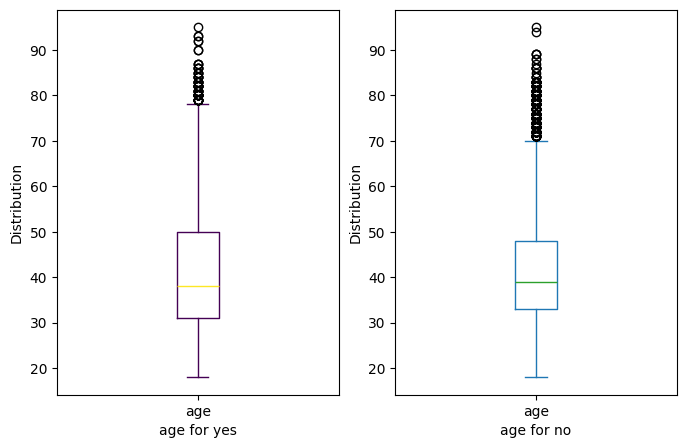

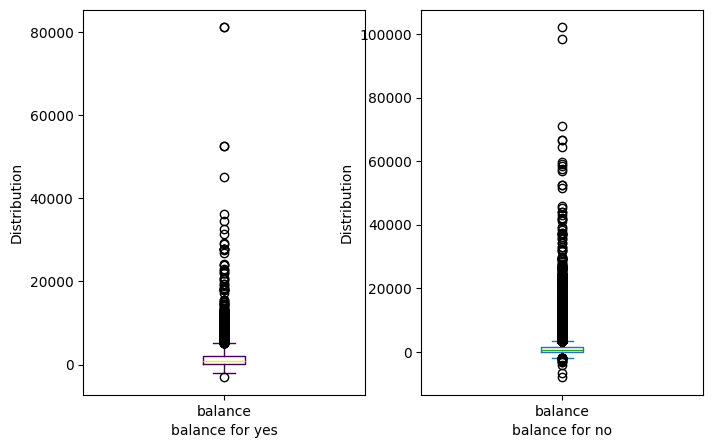

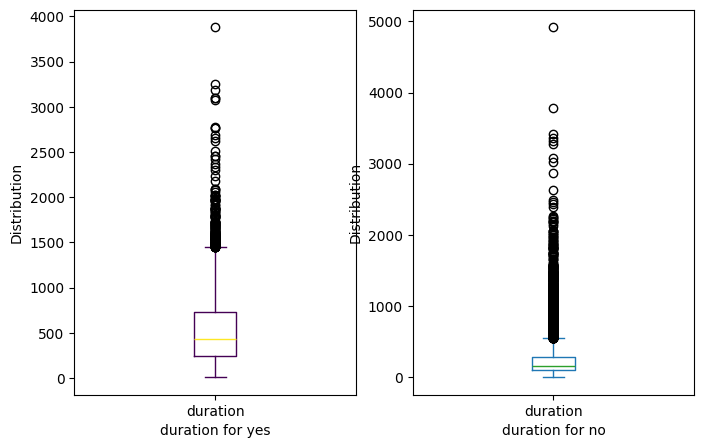

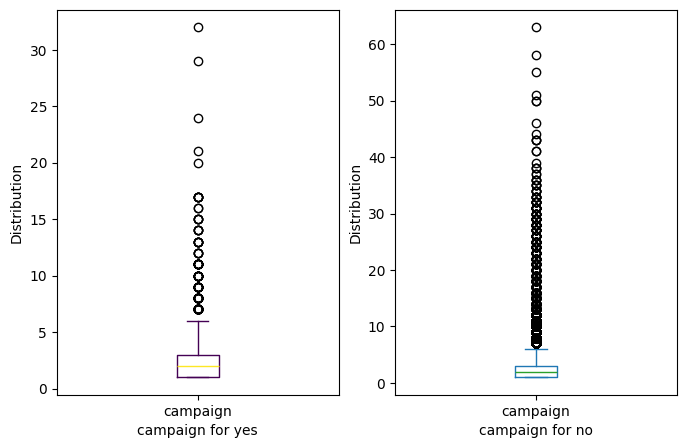

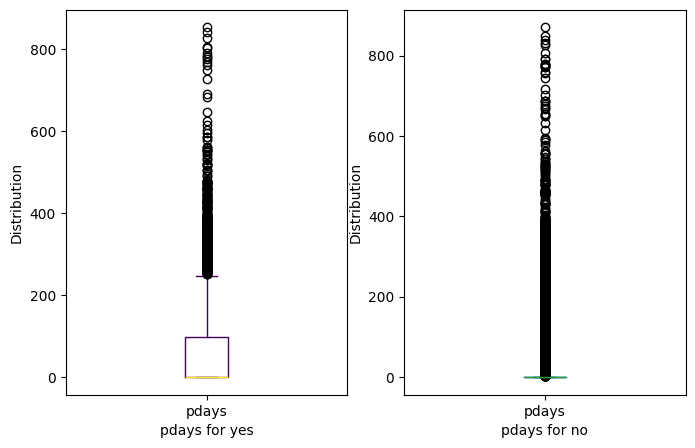

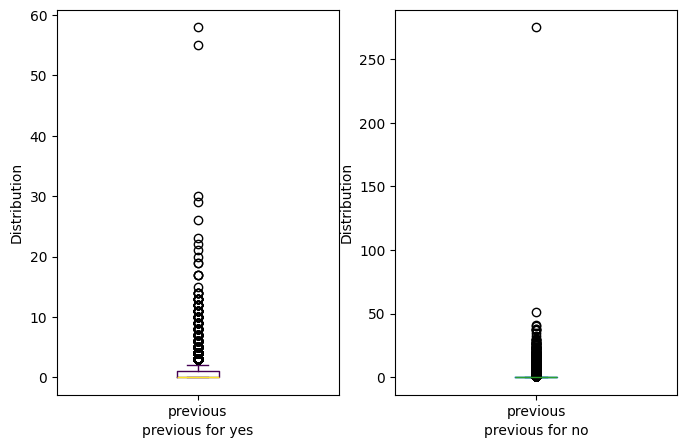

In [27]:
numeric=['age', 'balance', 'duration', 'campaign','pdays', 'previous']
for i in numeric:
    plt.figure(figsize=(8,5))
    plt.subplot(1,2,1)
    df[ df['y'] == 'yes'][i].plot(kind='box',colormap='viridis')
    plt.xlabel(f'{i} for yes')
    plt.ylabel('Distribution')
    
    plt.subplot(1,2,2)
    df[ df['y'] == 'no'][i].plot(kind='box')
    plt.xlabel(f'{i} for no')
    plt.ylabel('Distribution')
    plt.show()


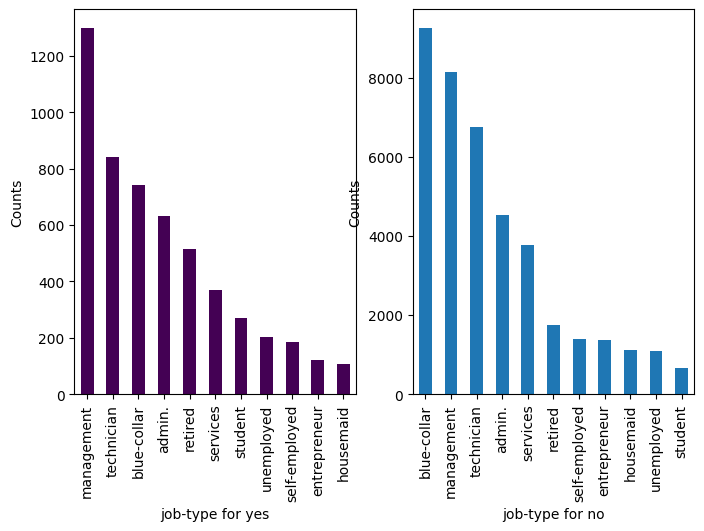

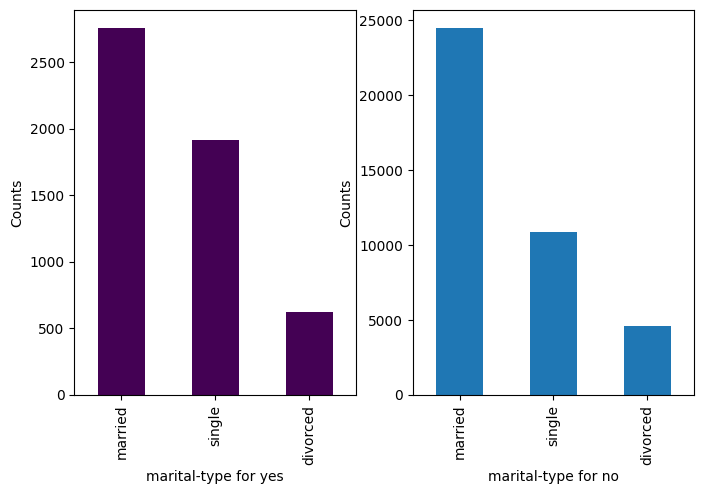

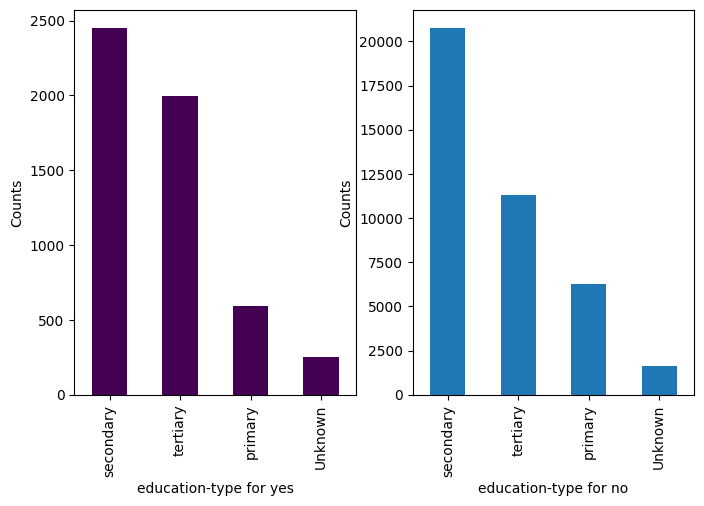

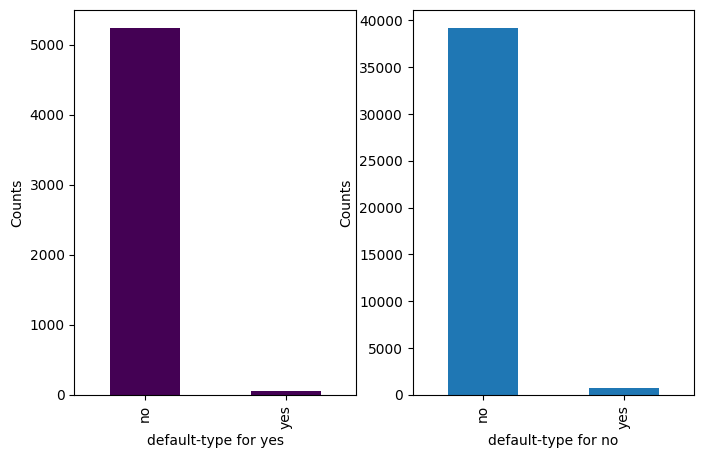

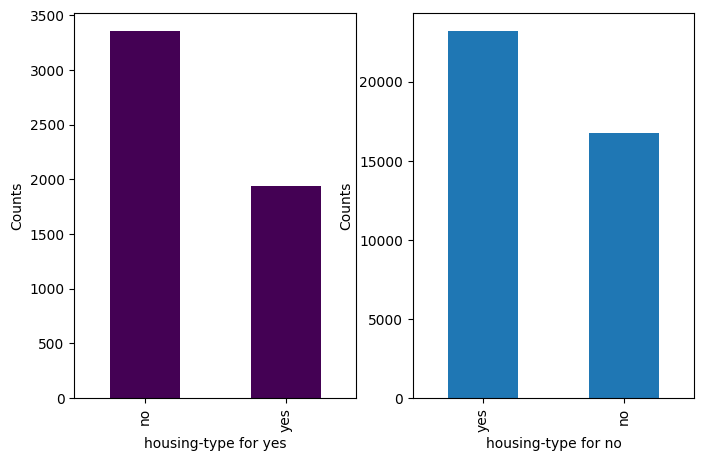

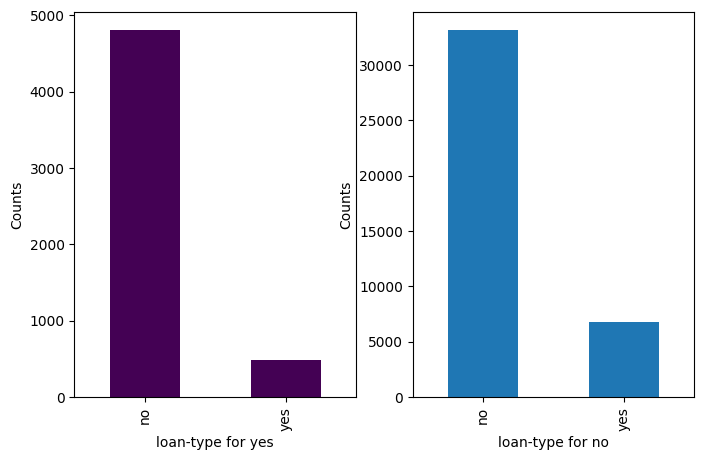

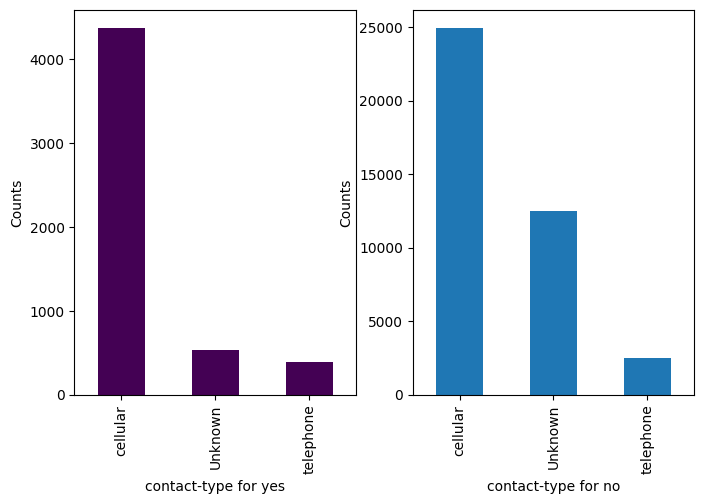

In [28]:
categorical=['job', 'marital', 'education', 'default', 'housing',
       'loan', 'contact']

for i in categorical:
    plt.figure(figsize=(8,5))
    plt.subplot(1,2,1)
    df[ df['y'] == 'yes'][i].value_counts().plot(kind='bar',colormap='viridis')
    plt.xlabel(f'{i}-type for yes')
    plt.ylabel('Counts')
    
    plt.subplot(1,2,2)
    df[ df['y'] == 'no'][i].value_counts().plot(kind='bar')
    plt.xlabel(f'{i}-type for no')
    plt.ylabel('Counts')
    plt.show()


In [29]:
df['y']=df['y'].apply(lambda x: 1 if x=='yes' else 0)

In [30]:
df['y'].value_counts()

y
0    39922
1     5289
Name: count, dtype: int64

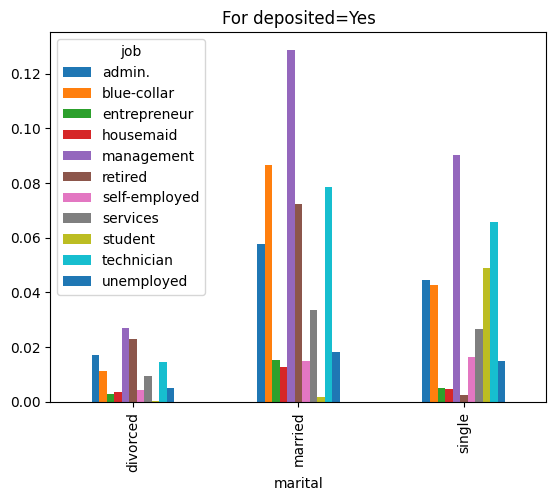

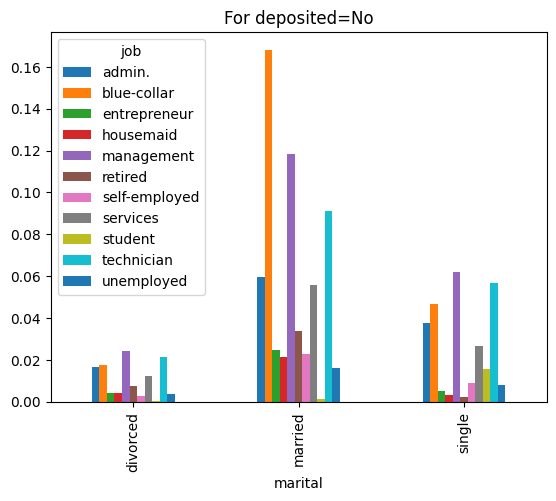

In [32]:
yes_depo=df[ df['y'] == 1]
no_depo=df[ df['y'] == 0]

pd.crosstab(yes_depo['marital'],values=yes_depo['job'],columns=yes_depo['job'],aggfunc='count',normalize=True).plot(kind='bar')
plt.title('For deposited=Yes')

pd.crosstab(no_depo['marital'],values=no_depo['job'],columns=no_depo['job'],aggfunc='count',normalize=True).plot(kind='bar')
plt.title('For deposited=No')
plt.show()

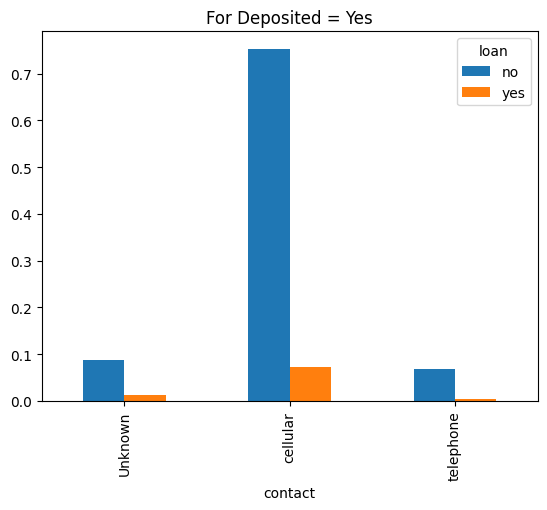

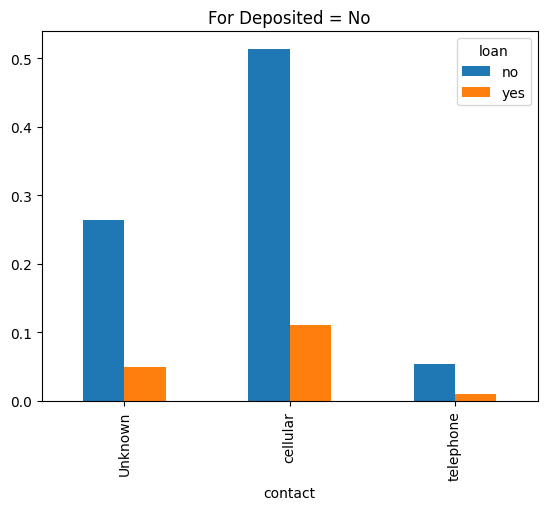

In [35]:
pd.crosstab(yes_depo['contact'],values=yes_depo['loan'],columns=yes_depo['loan'],aggfunc='count',normalize=True).plot(kind='bar')
plt.title('For Deposited = Yes')

pd.crosstab(no_depo['contact'],values=no_depo['loan'],columns=no_depo['loan'],aggfunc='count',normalize=True).plot(kind='bar')
plt.title('For Deposited = No')
plt.show()

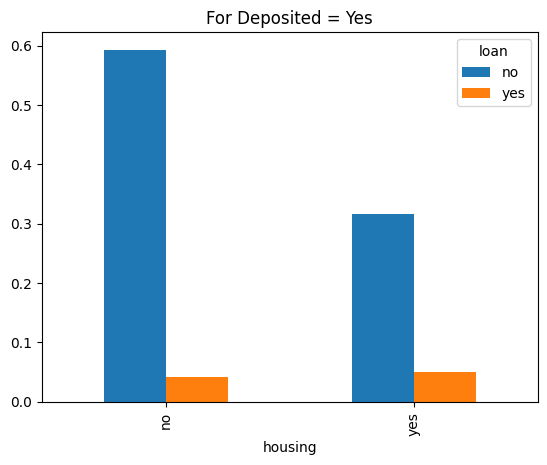

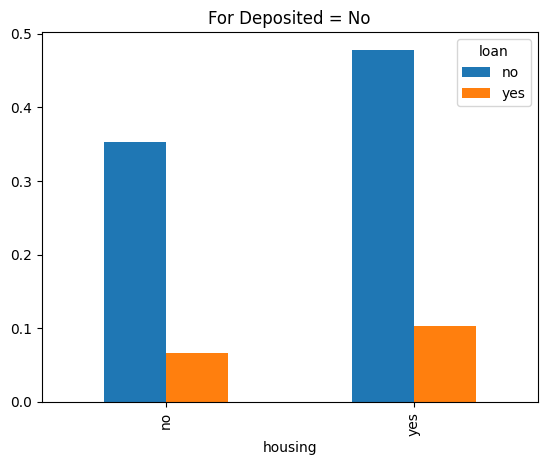

In [36]:
pd.crosstab(yes_depo['housing'],values=yes_depo['loan'],columns=yes_depo['loan'],aggfunc='count',normalize=True).plot(kind='bar')
plt.title('For Deposited = Yes')

pd.crosstab(no_depo['housing'],values=no_depo['loan'],columns=no_depo['loan'],aggfunc='count',normalize=True).plot(kind='bar')
plt.title('For Deposited = No')
plt.show()

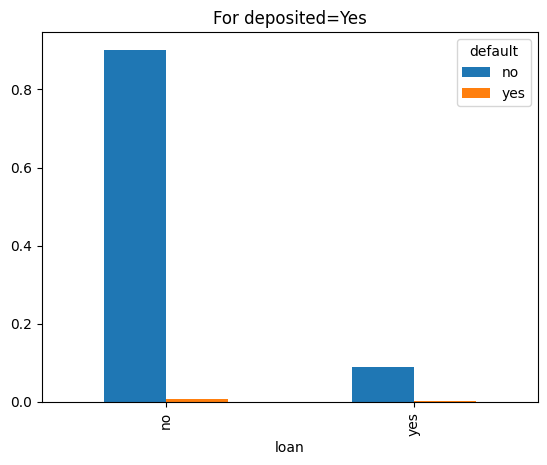

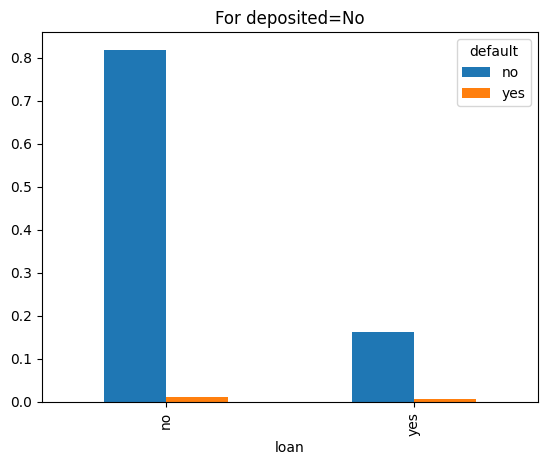

In [37]:
pd.crosstab(yes_depo['loan'],values=yes_depo['default'],columns=yes_depo['default'],aggfunc='count',normalize=True).plot(kind='bar')
plt.title('For deposited=Yes')

pd.crosstab(no_depo['loan'],values=no_depo['default'],columns=no_depo['default'],aggfunc='count',normalize=True).plot(kind='bar')
plt.title('For deposited=No')
plt.show()


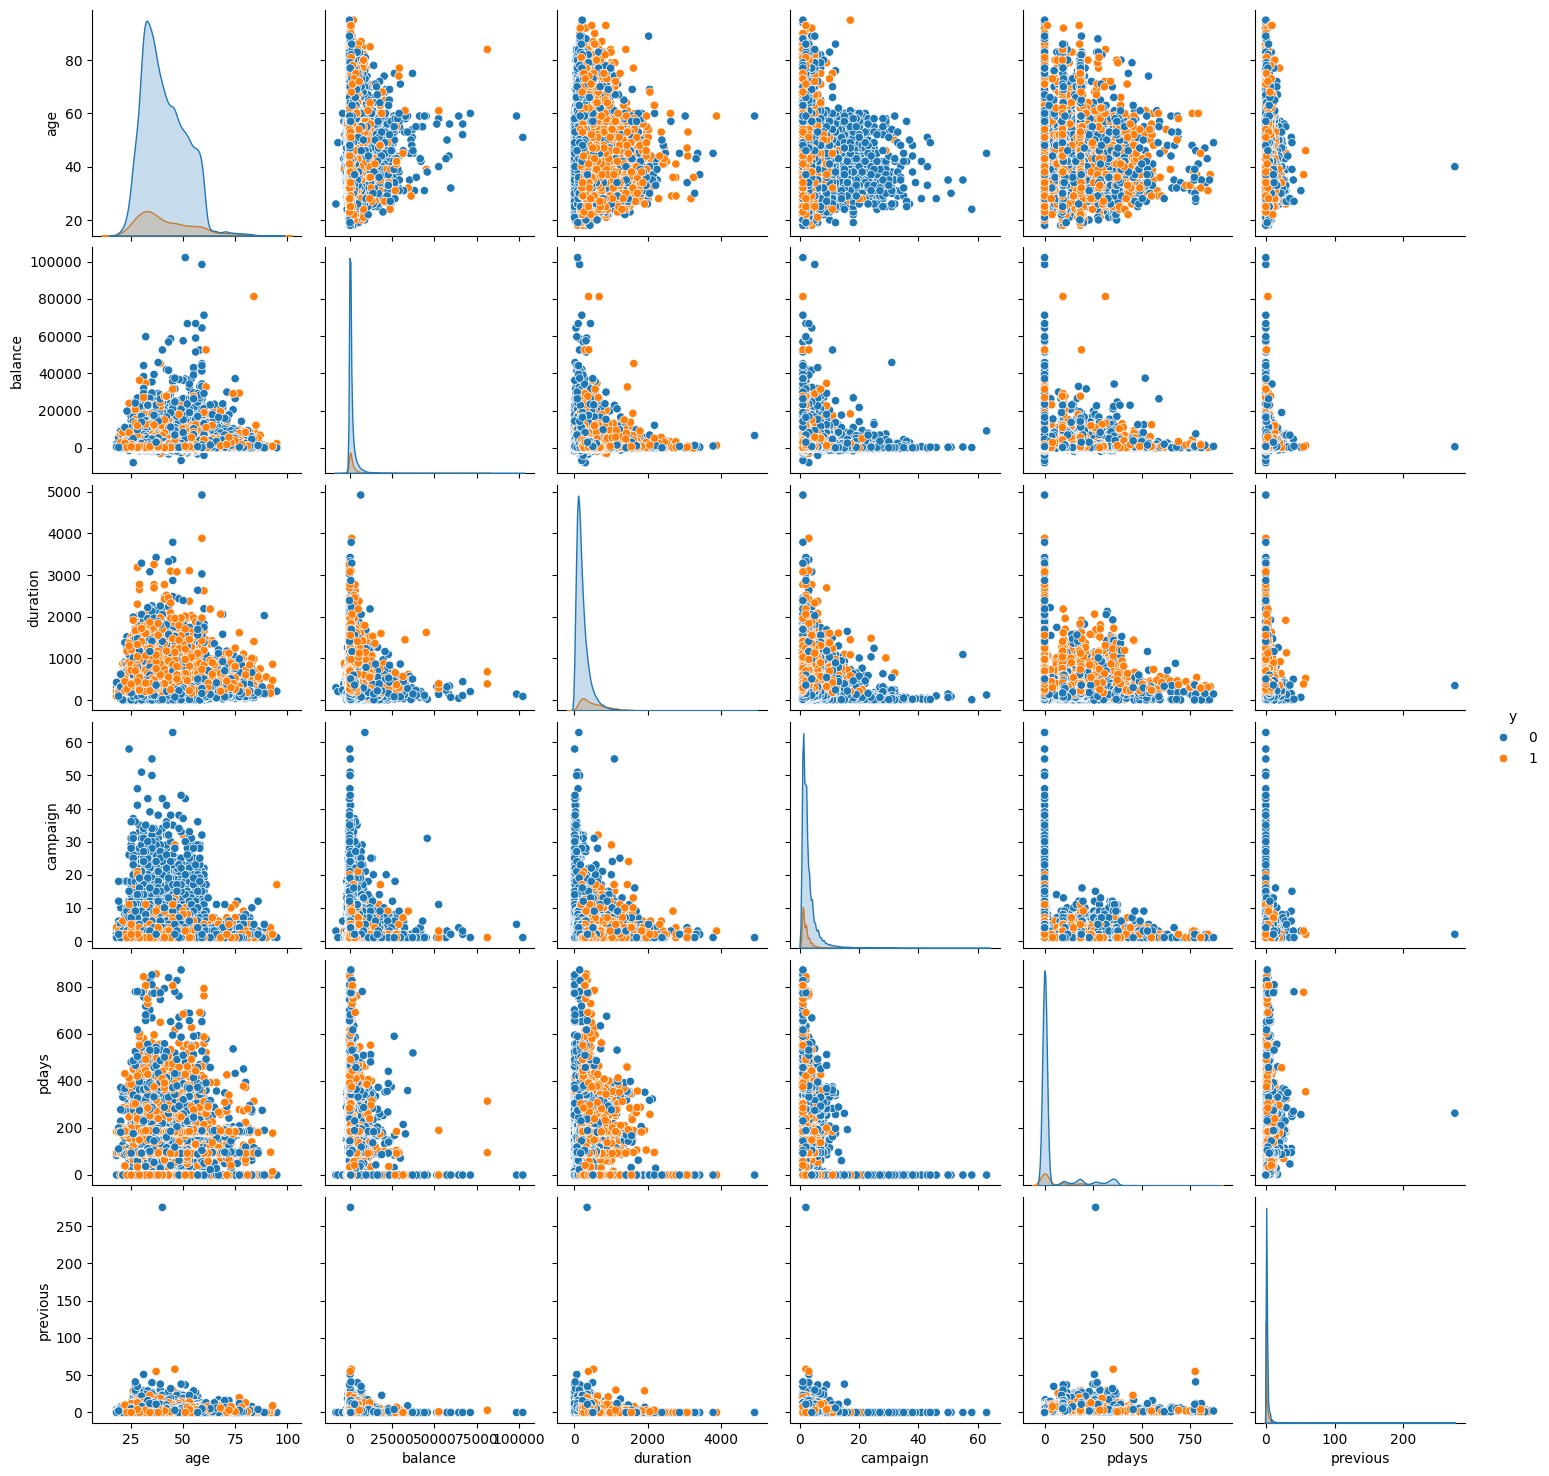

In [38]:
sns.pairplot(data=df[['age', 'balance', 'duration', 'campaign','pdays', 'previous','y']],hue='y')


In [45]:
df.to_csv('bank-marketing-cleaned.csv',index=False)